In [3]:
print("=== PROJECT OBJECTIVE ===")
print("The goal of this project is to analyze football match data and understand the factors that influence match outcomes.")

=== PROJECT OBJECTIVE ===
The goal of this project is to analyze football match data and understand the factors that influence match outcomes.


/kaggle/input/datasets/thefc17/epl-results-19932018/EPL_Set.csv
/kaggle/input/datasets/irkaal/english-premier-league-results/results.parquet
/kaggle/input/datasets/irkaal/english-premier-league-results/results.feather
/kaggle/input/datasets/irkaal/english-premier-league-results/results.csv
    Season              DateTime     HomeTeam        AwayTeam  FTHG  FTAG FTR  \
0  1993-94  1993-08-14T00:00:00Z      Arsenal        Coventry     0     3   A   
1  1993-94  1993-08-14T00:00:00Z  Aston Villa             QPR     4     1   H   
2  1993-94  1993-08-14T00:00:00Z      Chelsea       Blackburn     1     2   A   
3  1993-94  1993-08-14T00:00:00Z    Liverpool  Sheffield Weds     2     0   H   
4  1993-94  1993-08-14T00:00:00Z     Man City           Leeds     1     1   D   

   HTHG  HTAG  HTR  ... HST  AST  HC  AC  HF  AF  HY  AY  HR  AR  
0   NaN   NaN  NaN  ... NaN  NaN NaN NaN NaN NaN NaN NaN NaN NaN  
1   NaN   NaN  NaN  ... NaN  NaN NaN NaN NaN NaN NaN NaN NaN NaN  
2   NaN   NaN  NaN  .

,HomeTeam,AwayTeam,HomeGoals,AwayGoals,Result
0,Arsenal,Coventry,0,3,A
1,Aston Villa,QPR,4,1,H
2,Chelsea,Blackburn,1,2,A
3,Liverpool,Sheffield Weds,2,0,H
4,Man City,Leeds,1,1,D


=== BASIC ANALYSIS ===
Home Win Rate: 45.78%
Draw Rate: 25.77%
Away Win Rate: 28.44%

Observation: Home teams tend to win more often, which suggests a home advantage in football matches.

===== BASIC INSIGHTS =====
Home Win Rate: 45.78%
Draw Rate: 25.77%
Away Win Rate: 28.44%
Average Home Goals: 1.52
Average Away Goals: 1.14
Average Total Goals per Match: 2.66


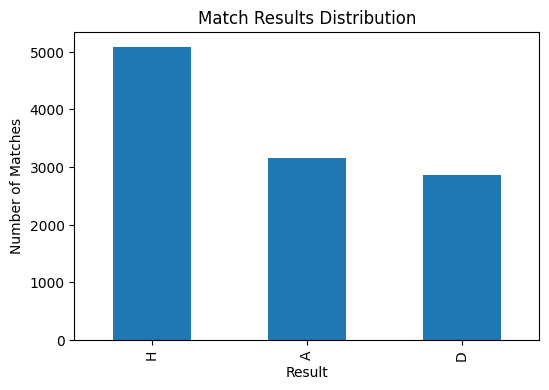

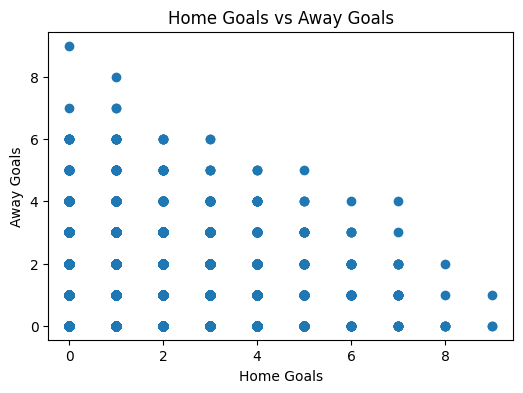


===== TOP HOME TEAMS BY HOME WIN RATE =====
          Team  Average Home Goals Scored  Average Home Goals Conceded  \
27  Man United                   2.115942                     0.744565   
0      Arsenal                   2.027174                     0.844203   
25   Liverpool                   2.005445                     0.794918   
14     Chelsea                   1.970909                     0.827273   
26    Man City                   1.997807                     0.942982   
43   Tottenham                   1.720508                     1.072595   
29   Newcastle                   1.610136                     1.148148   
4    Blackburn                   1.550459                     1.110092   
23       Leeds                   1.463710                     1.068548   
18     Everton                   1.539020                     1.101633   

    Home Win Rate  
27      69.927536  
0       64.673913  
25      62.976407  
14      62.363636  
26      58.991228  
43      53.901996  


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


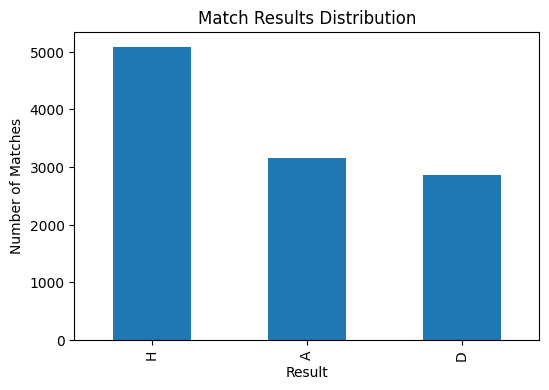

This graph shows how often each match outcome occurs.
=== FINAL INTERPRETATION ===
This project explores football match outcomes using match statistics.
The model achieves moderate accuracy, but it uses variables derived from match results, which limits its predictive validity.
This highlights that predicting football outcomes requires pre-match features such as team form, historical performance, and player data.
Therefore, this project focuses more on understanding patterns rather than building a fully reliable predictive model.

Project completed successfully.
Cleaned dataset saved as cleaned_football_data.csv


In [4]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))


file_path = "/kaggle/input/datasets/irkaal/english-premier-league-results/results.csv"

df = pd.read_csv(file_path, encoding="latin1")


print(df.head())
print(df.columns)




df = df[["HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]]

# 5. Drop missing values
df = df.dropna()




df = df.rename(columns={
    "FTHG": "HomeGoals",
    "FTAG": "AwayGoals",
    "FTR": "Result"
})



print("=== DATASET PREVIEW ===")
display(df.head())




print("=== BASIC ANALYSIS ===")

home_win_rate = (df["Result"] == "H").mean() * 100
draw_rate = (df["Result"] == "D").mean() * 100
away_win_rate = (df["Result"] == "A").mean() * 100

print(f"Home Win Rate: {home_win_rate:.2f}%")
print(f"Draw Rate: {draw_rate:.2f}%")
print(f"Away Win Rate: {away_win_rate:.2f}%")

print("\nObservation: Home teams tend to win more often, which suggests a home advantage in football matches.")





df["GoalDifference"] = df["HomeGoals"] - df["AwayGoals"]
df["TotalGoals"] = df["HomeGoals"] + df["AwayGoals"]

df["HomeWin"] = df["Result"].apply(lambda x: 1 if x == "H" else 0)
df["Draw"] = df["Result"].apply(lambda x: 1 if x == "D" else 0)
df["AwayWin"] = df["Result"].apply(lambda x: 1 if x == "A" else 0)






home_win_rate = (df["Result"] == "H").mean() * 100
draw_rate = (df["Result"] == "D").mean() * 100
away_win_rate = (df["Result"] == "A").mean() * 100

avg_home_goals = df["HomeGoals"].mean()
avg_away_goals = df["AwayGoals"].mean()
avg_total_goals = df["TotalGoals"].mean()

print("\n===== BASIC INSIGHTS =====")
print(f"Home Win Rate: {home_win_rate:.2f}%")
print(f"Draw Rate: {draw_rate:.2f}%")
print(f"Away Win Rate: {away_win_rate:.2f}%")
print(f"Average Home Goals: {avg_home_goals:.2f}")
print(f"Average Away Goals: {avg_away_goals:.2f}")
print(f"Average Total Goals per Match: {avg_total_goals:.2f}")




plt.figure(figsize=(6, 4))
df["Result"].value_counts().plot(kind="bar")
plt.title("Match Results Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.show()





plt.figure(figsize=(6, 4))
plt.scatter(df["HomeGoals"], df["AwayGoals"])
plt.title("Home Goals vs Away Goals")
plt.xlabel("Home Goals")
plt.ylabel("Away Goals")
plt.show()




home_team_stats = df.groupby("HomeTeam").agg({
    "HomeGoals": "mean",
    "AwayGoals": "mean",
    "HomeWin": "mean"
}).reset_index()

home_team_stats.columns = [
    "Team",
    "Average Home Goals Scored",
    "Average Home Goals Conceded",
    "Home Win Rate"
]

home_team_stats["Home Win Rate"] = home_team_stats["Home Win Rate"] * 100

print("\n===== TOP HOME TEAMS BY HOME WIN RATE =====")
print(home_team_stats.sort_values(by="Home Win Rate", ascending=False).head(10))


away_team_stats = df.groupby("AwayTeam").agg({
    "AwayGoals": "mean",
    "HomeGoals": "mean",
    "AwayWin": "mean"
}).reset_index()

away_team_stats.columns = [
    "Team",
    "Average Away Goals Scored",
    "Average Away Goals Conceded",
    "Away Win Rate"
]

away_team_stats["Away Win Rate"] = away_team_stats["Away Win Rate"] * 100

print("\n===== TOP AWAY TEAMS BY AWAY WIN RATE =====")
print(away_team_stats.sort_values(by="Away Win Rate", ascending=False).head(10))




label_encoder = LabelEncoder()
df["ResultEncoded"] = label_encoder.fit_transform(df["Result"])

X = df[["TotalGoals"]]
y = df["ResultEncoded"]




X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)




model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)



predictions = model.predict(X_test)




accuracy = accuracy_score(y_test, predictions)

print("\n===== MODEL PERFORMANCE =====")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))




feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n===== FEATURE IMPORTANCE =====")
print(feature_importance)

plt.figure(figsize=(6,4))
df["Result"].value_counts().plot(kind="bar")
plt.title("Match Results Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.show()

print("This graph shows how often each match outcome occurs.")


print("=== FINAL INTERPRETATION ===")

print("This project explores football match outcomes using match statistics.")
print("The model achieves moderate accuracy, but it uses variables derived from match results, which limits its predictive validity.")
print("This highlights that predicting football outcomes requires pre-match features such as team form, historical performance, and player data.")
print("Therefore, this project focuses more on understanding patterns rather than building a fully reliable predictive model.")



df.to_csv("cleaned_football_data.csv", index=False)

print("\nProject completed successfully.")
print("Cleaned dataset saved as cleaned_football_data.csv")